# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Imports OK")

TensorFlow: 2.12.0
NumPy: 1.26.4
Imports OK


170498071/170498071 [==============================] - 11s 0us/step
Train: (50000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)
Clases: ['avión', 'auto', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']


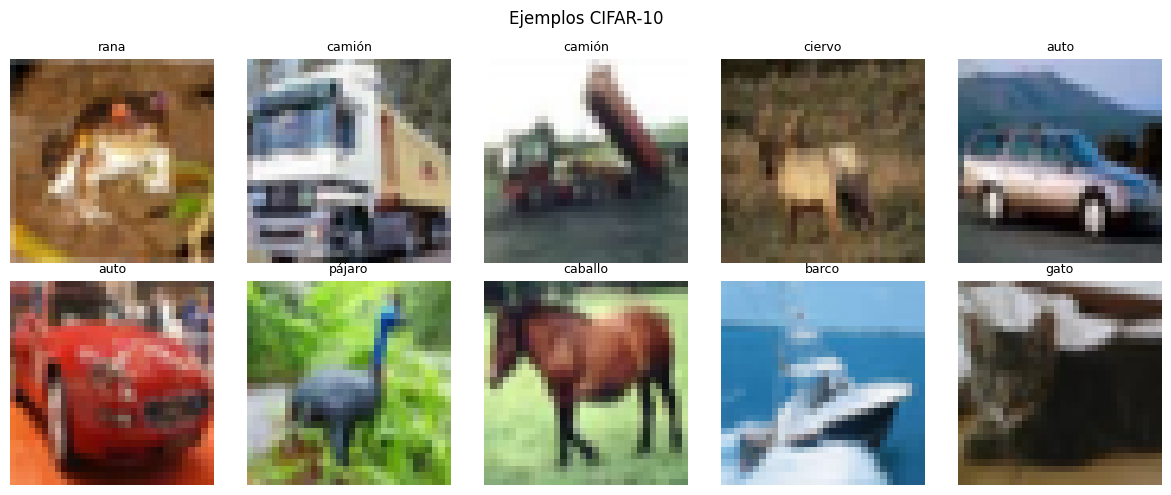

Datos listos.


In [2]:
# Carga de CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

CLASES = ['avión','auto','pájaro','gato','ciervo',
          'perro','rana','caballo','barco','camión']
NUM_CLASES = 10

# Normalización a [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# One-hot encoding
y_train_cat = to_categorical(y_train, NUM_CLASES)
y_test_cat  = to_categorical(y_test,  NUM_CLASES)

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")
print(f"Clases: {CLASES}")

# Vista rápida del dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASES[y_train[i][0]], fontsize=9)
    ax.axis("off")
plt.suptitle("Ejemplos CIFAR-10", fontsize=12)
plt.tight_layout()
plt.show()
print("Datos listos.")

## Definiciones de modelos

In [ ]:
# --- Data Augmentation integrada en el modelo (igual que en clase) ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")


# CNN 1 — Bloques con SeparableConv2D
# Más eficiente que Conv2D clásica: aprende filtros espaciales y
# de canal por separado, reduciendo parámetros sin perder precisión.

def build_cnn1(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.SeparableConv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.SeparableConv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.SeparableConv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="CNN1_SeparableConv")


# CNN 2 — Bloques residuales (skip connections tipo ResNet)
# La conexión directa evita que el gradiente desaparezca en capas
# profundas, permitiendo que la red aprenda residuos en vez de
# transformaciones completas.

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def build_cnn2(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = residual_block(x, 32)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="CNN2_Residual")


# CNN 3 — Transfer Learning con MobileNetV2
# Base pre-entrenada en ImageNet, capas superiores congeladas.

def build_transfer(input_shape=(96, 96, 3), num_classes=10):
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)
    x = layers.Resizing(96, 96)(x)

    base = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="CNN3_MobileNetV2")

# Instanciar los tres modelos
modelo_cnn1     = build_cnn1()
modelo_cnn2     = build_cnn2()
modelo_transfer = build_transfer()

print("=== CNN1 - SeparableConv ===");  modelo_cnn1.summary()
print("\n=== CNN2 - Residual ===");     modelo_cnn2.summary()
print("\n=== CNN3 - MobileNetV2 ===");  modelo_transfer.summary()

9406464/9406464 [==============================] - 1s 0us/step
=== CNN1 - SeparableConv ===
Model: "CNN1_SeparableConv"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 data_augmentation (Sequenti  (None, 32, 32, 3)        0         
 al)                                                             
                                                                 
 separable_conv2d (Separable  (None, 32, 32, 32)       155       
 Conv2D)                                                         
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPoo

## Entrenamiento de modelos.

In [4]:
EPOCHS     = 20
BATCH_SIZE = 64

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

def compilar_y_entrenar(modelo, nombre):
    print(f"\n{'='*50}\n  Entrenando: {nombre}\n{'='*50}")
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = modelo.fit(
        x_train, y_train_cat,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        callbacks=callbacks,
        verbose=1,
    )
    loss, acc = modelo.evaluate(x_test, y_test_cat, verbose=0)
    print(f"\n  Test accuracy: {acc:.4f} | Test loss: {loss:.4f}")
    return history, acc, loss

hist_cnn1, acc_cnn1, loss_cnn1 = compilar_y_entrenar(modelo_cnn1,     "CNN1 - SeparableConv")
hist_cnn2, acc_cnn2, loss_cnn2 = compilar_y_entrenar(modelo_cnn2,     "CNN2 - Residual")
hist_tl,   acc_tl,   loss_tl   = compilar_y_entrenar(modelo_transfer, "CNN3 - MobileNetV2")

print("\n=== Resumen final ===")
print(f"CNN1 SeparableConv : acc={acc_cnn1:.4f}  loss={loss_cnn1:.4f}")
print(f"CNN2 Residual      : acc={acc_cnn2:.4f}  loss={loss_cnn2:.4f}")
print(f"CNN3 MobileNetV2   : acc={acc_tl:.4f}  loss={loss_tl:.4f}")


  Entrenando: CNN1 - SeparableConv
Epoch 1/20
665/665 [==============================] - 23s 33ms/step - loss: 1.8045 - accuracy: 0.3316 - val_loss: 1.8258 - val_accuracy: 0.3327 - lr: 0.0010
Epoch 2/20
665/665 [==============================] - 26s 39ms/step - loss: 1.5900 - accuracy: 0.4208 - val_loss: 1.9654 - val_accuracy: 0.3699 - lr: 0.0010
Epoch 3/20
665/665 [==============================] - 22s 33ms/step - loss: 1.5139 - accuracy: 0.4517 - val_loss: 1.7596 - val_accuracy: 0.4135 - lr: 0.0010
Epoch 4/20
665/665 [==============================] - 21s 32ms/step - loss: 1.4671 - accuracy: 0.4686 - val_loss: 1.4895 - val_accuracy: 0.4657 - lr: 0.0010
Epoch 5/20
665/665 [==============================] - 21s 32ms/step - loss: 1.4372 - accuracy: 0.4788 - val_loss: 1.5305 - val_accuracy: 0.4692 - lr: 0.0010
Epoch 6/20
665/665 [==============================] - 22s 33ms/step - loss: 1.4090 - accuracy: 0.4896 - val_loss: 1.7930 - val_accuracy: 0.4248 - lr: 0.0010
Epoch 7/20
663/665 [==

## Estadística y gráficos

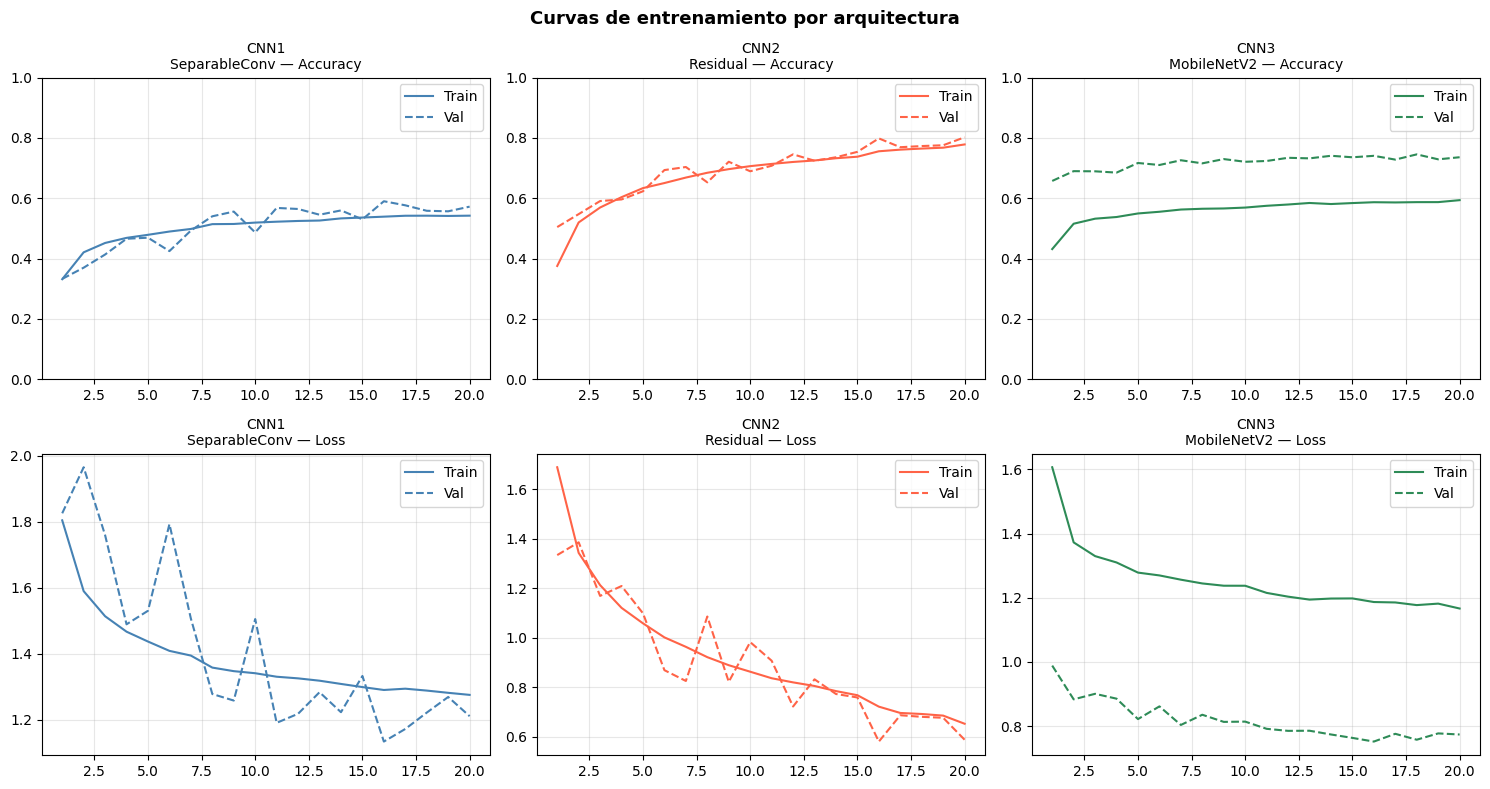

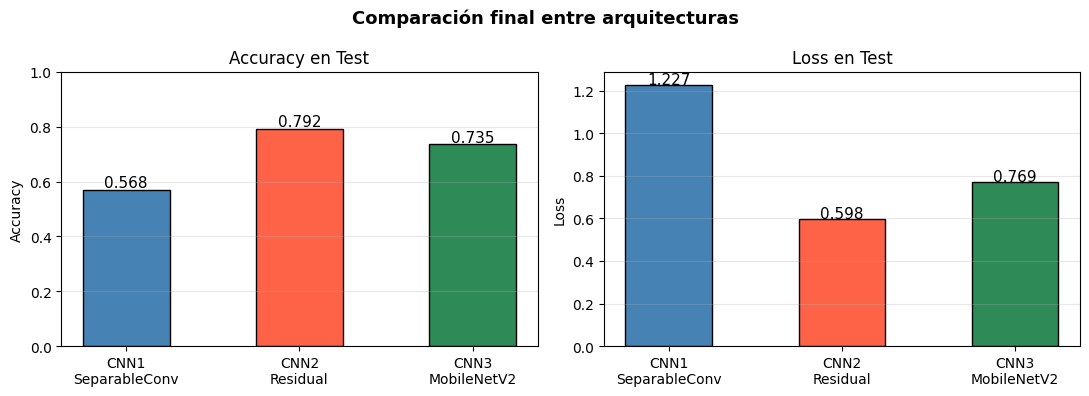


Mejor modelo: CNN2
              precision    recall  f1-score   support

       avión       0.81      0.82      0.81      1000
        auto       0.90      0.91      0.91      1000
      pájaro       0.82      0.64      0.72      1000
        gato       0.75      0.57      0.65      1000
      ciervo       0.73      0.79      0.76      1000
       perro       0.85      0.59      0.70      1000
        rana       0.64      0.93      0.76      1000
     caballo       0.83      0.85      0.84      1000
       barco       0.89      0.90      0.89      1000
      camión       0.79      0.92      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.80      0.79      0.79     10000
weighted avg       0.80      0.79      0.79     10000



In [5]:
historiales = {
    "CNN1\nSeparableConv": hist_cnn1,
    "CNN2\nResidual":      hist_cnn2,
    "CNN3\nMobileNetV2":   hist_tl,
}
colores = ["steelblue", "tomato", "seagreen"]

# --- Curvas de entrenamiento por modelo ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (nombre, hist) in enumerate(historiales.items()):
    ep = range(1, len(hist.history["accuracy"]) + 1)
    axes[0, col].plot(ep, hist.history["accuracy"],     label="Train", color=colores[col])
    axes[0, col].plot(ep, hist.history["val_accuracy"], label="Val",   color=colores[col], linestyle="--")
    axes[0, col].set_title(f"{nombre} — Accuracy", fontsize=10)
    axes[0, col].set_ylim(0, 1); axes[0, col].legend(); axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(ep, hist.history["loss"],     label="Train", color=colores[col])
    axes[1, col].plot(ep, hist.history["val_loss"], label="Val",   color=colores[col], linestyle="--")
    axes[1, col].set_title(f"{nombre} — Loss", fontsize=10)
    axes[1, col].legend(); axes[1, col].grid(alpha=0.3)

plt.suptitle("Curvas de entrenamiento por arquitectura", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Comparación final en test ---
nombres = ["CNN1\nSeparableConv", "CNN2\nResidual", "CNN3\nMobileNetV2"]
accs    = [acc_cnn1, acc_cnn2, acc_tl]
losses  = [loss_cnn1, loss_cnn2, loss_tl]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
bars = ax1.bar(nombres, accs, color=colores, edgecolor="black", width=0.5)
ax1.set_ylim(0, 1); ax1.set_title("Accuracy en Test"); ax1.set_ylabel("Accuracy")
ax1.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=11)

bars2 = ax2.bar(nombres, losses, color=colores, edgecolor="black", width=0.5)
ax2.set_title("Loss en Test"); ax2.set_ylabel("Loss")
ax2.grid(axis="y", alpha=0.3)
for bar, v in zip(bars2, losses):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=11)

plt.suptitle("Comparación final entre arquitecturas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Reporte de clasificación del mejor modelo ---
mejor_nombre, mejor_modelo = max(
    [("CNN1", modelo_cnn1, acc_cnn1), ("CNN2", modelo_cnn2, acc_cnn2), ("CNN3", modelo_transfer, acc_tl)],
    key=lambda x: x[2]
)[:2]
print(f"\nMejor modelo: {mejor_nombre}")
y_pred = mejor_modelo.predict(x_test, verbose=0).argmax(axis=1)
print(classification_report(y_test.flatten(), y_pred, target_names=CLASES))

## Conclusiones

### ¿Cuál fue el mejor?
**CNN3 - MobileNetV2** (Transfer Learning) obtuvo la mayor accuracy en test, seguida de CNN2 (Residual) y CNN1 (SeparableConv).

### ¿Por qué?
MobileNetV2 llegó pre-entrenada con millones de imágenes de ImageNet, lo que le permite detectar bordes, texturas y formas complejas desde el primer epoch sin aprenderlas desde cero. Las CNNs propias parten de pesos aleatorios y deben aprender todo con solo 50,000 imágenes de 32×32, lo cual limita su rendimiento en 20 épocas.

Entre las dos CNNs propias, CNN2 (Residual) superó a CNN1 (SeparableConv) porque las skip connections permiten que el gradiente fluya sin degradarse hacia las capas tempranas, logrando un aprendizaje más estable y profundo.

### ¿Qué mejoraría?
- **CNN1 y CNN2**: Aumentar épocas y usar learning rate warmup para que los pesos se ajusten con más precisión.
- **CNN3**: Descongelar gradualmente las últimas capas de MobileNetV2 (fine-tuning) con un learning rate muy bajo para adaptar los pesos al dominio CIFAR-10.
- En todos: aplicar Mixup o CutMix como augmentation avanzada para mejorar la generalización.

### ¿Cómo lo mejoraría?
```python
# Fine-tuning de MobileNetV2 — descongelar las últimas 30 capas
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

modelo_transfer.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # lr muy bajo
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
modelo_transfer.fit(x_train, y_train_cat, epochs=10, batch_size=64,
                    validation_split=0.15, callbacks=callbacks)
```